# Data preparation and exploration

## Setup and imports

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../'
  SRC = f"{PROJECT_ROOT}/src"
  if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
  if SRC not in sys.path:
    sys.path.append(SRC)

In [2]:
# %pip install -q tableone

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tableone import TableOne
from sklearn.feature_selection import mutual_info_regression
from sklearn.utils import resample
from analysis_utils import print_table_1

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1)

seed = 4

## Data import

In [3]:
heart_disease = pd.read_csv(f'{PROJECT_ROOT}/z_data/heart_disease_cleveland_hungary.csv')

# Remove duplicates and null values, as per Straw et al.

rows_to_drop  = (heart_disease['ST slope'] == 0) | (heart_disease['cholesterol'] == 0) | (heart_disease['resting bp s'] == 0) | (heart_disease.duplicated(keep='first'))
heart_disease.drop(heart_disease[rows_to_drop].index, inplace=True)

# Clip negative values of st (oldpeak)
heart_disease['oldpeak'] = heart_disease['oldpeak'].clip(lower=0)

# print(heart_disease.describe())

## Study population summary

In [4]:
from tableone import TableOne

# Descriptive statistics
table1 = TableOne(heart_disease,
                  groupby='sex',
                  continuous=['age','cholesterol','max heart rate','resting bp s','oldpeak'],
                  categorical=['target','chest pain type', 'fasting blood sugar','resting ecg','exercise angina','ST slope'],
                  missing=False
                  )

print(table1)

                             Grouped by sex                            
                                    Overall             0             1
n                                       745           182           563
age, mean (SD)                   52.9 (9.5)    52.2 (9.3)    53.1 (9.5)
chest pain type, n (%)     1       41 (5.5)       9 (4.9)      32 (5.7)
                           2     166 (22.3)     59 (32.4)    107 (19.0)
                           3     168 (22.6)     52 (28.6)    116 (20.6)
                           4     370 (49.7)     62 (34.1)    308 (54.7)
resting bp s, mean (SD)        133.0 (17.3)  132.0 (18.6)  133.3 (16.8)
cholesterol, mean (SD)         244.7 (59.2)  255.8 (62.9)  241.1 (57.5)
fasting blood sugar, n (%) 0     621 (83.4)    163 (89.6)    458 (81.3)
                           1     124 (16.6)     19 (10.4)    105 (18.7)
resting ecg, n (%)         0     444 (59.6)    109 (59.9)    335 (59.5)
                           1     125 (16.8)     26 (14.3)     99

In [5]:

heart_disease.rename(columns={'sex':'sex', 'chest pain type':'cp', 'resting bp s':'bp', 'cholesterol':'chol',
                              'fasting blood sugar':'fbs', 'resting ecg':'ecg', 'max heart rate':'mhr', 'exercise angina':'ang',
                              'oldpeak':'st', 'ST slope':'slope', 'target':'cvd'}, inplace=True)



## Raw data exploration

### Distributions

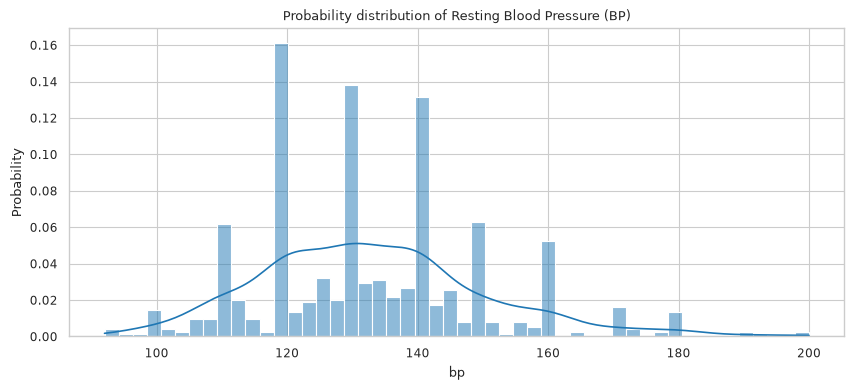

In [6]:
# BP distribution
plt.figure(figsize=(10, 4))
sns.histplot(heart_disease, x='bp', bins=50, kde=True, stat='probability')
plt.title('Probability distribution of Resting Blood Pressure (BP)')
plt.show()

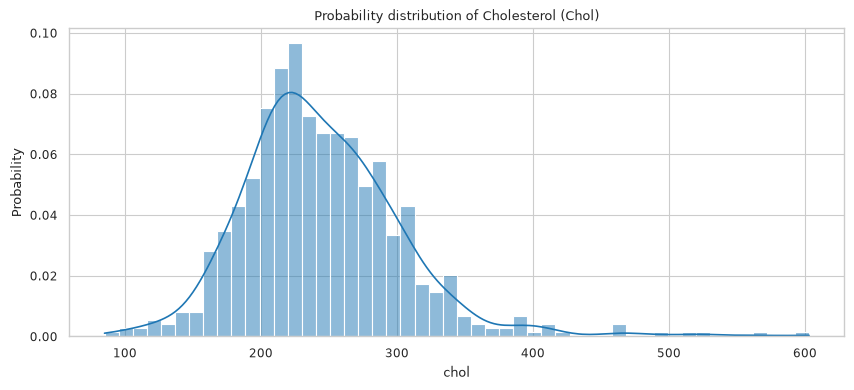

In [7]:
# Chol distribution
plt.figure(figsize=(10, 4))
sns.histplot(heart_disease, x='chol', bins=50, kde=True, stat='probability')
plt.title('Probability distribution of Cholesterol (Chol)')
plt.show()

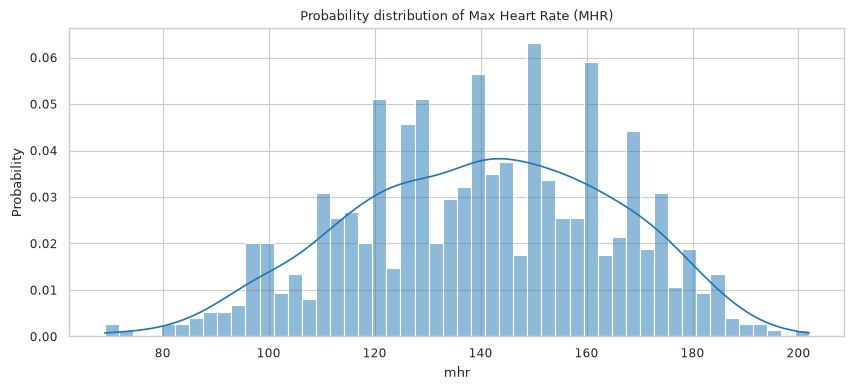

In [8]:
# MHR distribution
plt.figure(figsize=(10, 4))
sns.histplot(heart_disease, x='mhr', bins=50, kde=True, stat='probability')
plt.title('Probability distribution of Max Heart Rate (MHR)')
plt.show()

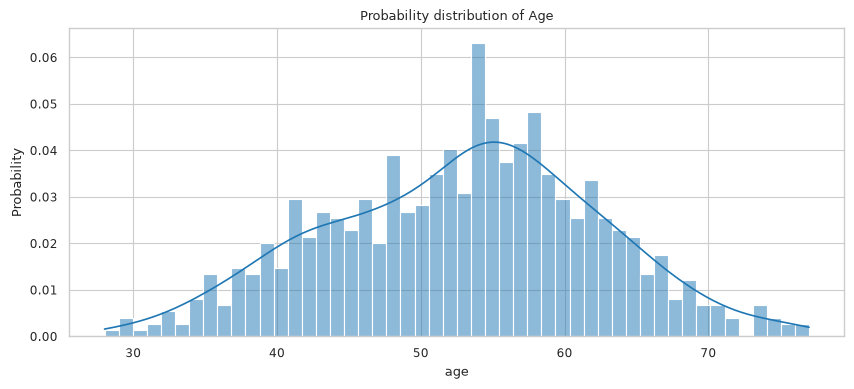

In [9]:
# Age distribution
plt.figure(figsize=(10, 4))
sns.histplot(heart_disease, x='age', bins=50, kde=True, stat='probability')
plt.title('Probability distribution of Age')
plt.show()

### Stratified distributions

In [10]:
def format_mean_std(col):
  return f'{col.mean():.2f} ± {col.std():.2f}'

def format_median(col):
  return f'{col.median():.2f}'

def stratified_stats(df, var):
  df = heart_disease.pivot_table(index=['cvd','sex'],
                                 values=var, aggfunc=[format_mean_std, format_median])
  df.columns = df.columns.droplevel()
  df.columns = ['Mean +- Std', 'Median']
  return df

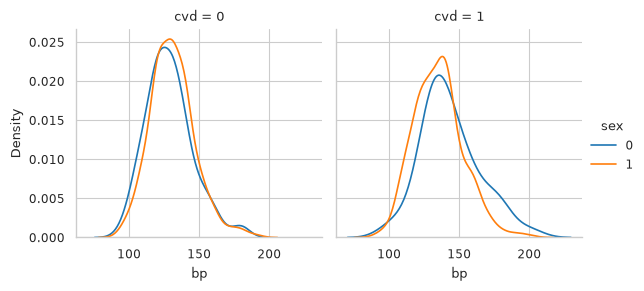



            Mean +- Std  Median
cvd sex                        
0   0    128.77 ± 16.69  130.00
    1    130.96 ± 15.79  130.00
1   0    143.38 ± 20.66  139.00
    1    135.19 ± 17.42  135.00


In [11]:
g = sns.FacetGrid(heart_disease, col="cvd", hue='sex')
g.map(sns.kdeplot, 'bp')
g.add_legend()
plt.show()

print('\n')
print(stratified_stats(heart_disease, 'bp'))

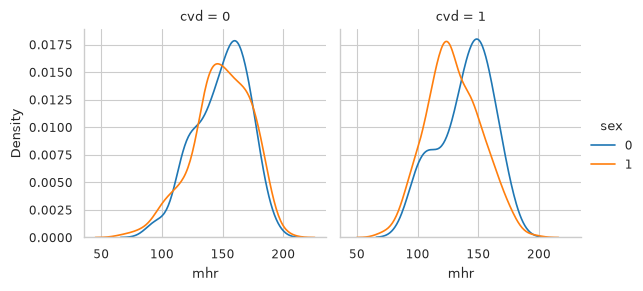



            Mean +- Std  Median
cvd sex                        
0   0    149.18 ± 21.61  152.00
    1    148.99 ± 23.97  150.00
1   0    139.25 ± 21.70  144.00
    1    129.44 ± 22.20  127.00


In [12]:
g = sns.FacetGrid(heart_disease, col="cvd", hue='sex')
g.map(sns.kdeplot, 'mhr')
g.add_legend()
plt.show()

print('\n')
print(stratified_stats(heart_disease, 'mhr'))

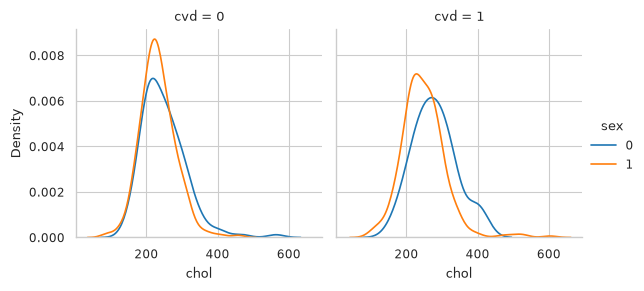



            Mean +- Std  Median
cvd sex                        
0   0    249.18 ± 62.23  238.50
    1    232.81 ± 50.24  227.00
1   0    279.18 ± 60.11  275.00
    1    247.67 ± 61.97  243.00


In [13]:
g = sns.FacetGrid(heart_disease, col="cvd", hue='sex')
g.map(sns.kdeplot, 'chol')
g.add_legend()
plt.show()

print('\n')
print(stratified_stats(heart_disease, 'chol'))

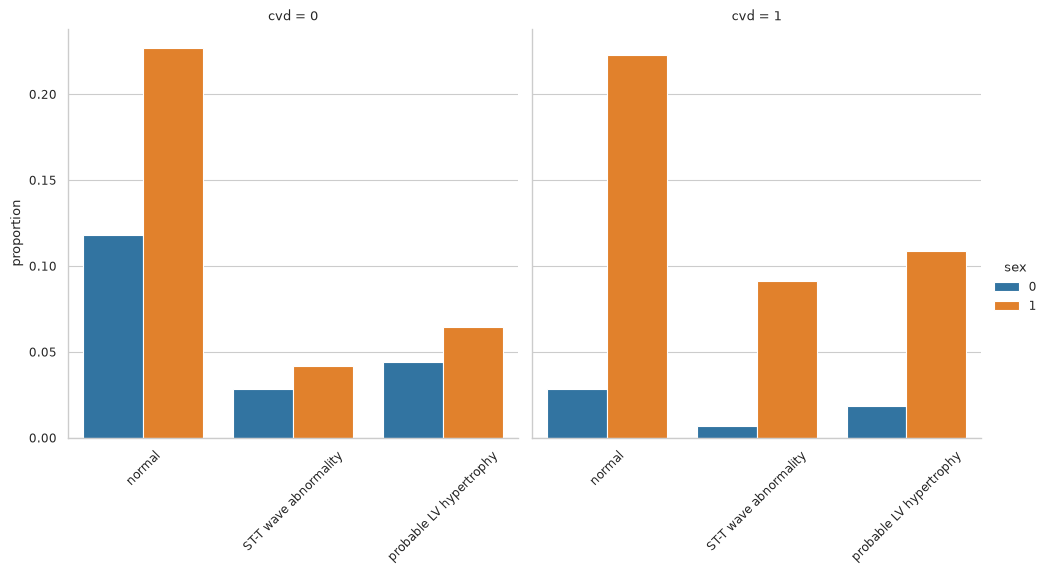

In [14]:
g = sns.catplot(data=heart_disease, x='ecg', col='cvd', kind='count', stat='proportion', hue='sex')
g.set_xticklabels(['normal','ST-T wave abnormality','probable LV hypertrophy'], rotation=45)
g.set_xlabels('')
plt.show()

## Mutual Information with sex

In [15]:
def mutual_info_with_sens(X, sens):
  N_MI = 100
  mi_results = []

  for i in range(N_MI):
    X_resampled, sens_resampled = resample(X, sens, n_samples=50, random_state=i)
    mi_scores = mutual_info_regression(X_resampled, sens_resampled, n_neighbors=5, random_state=seed)
    mi_results.append(mi_scores)

  mi_df = pd.DataFrame(mi_results, columns=X.columns)
  mi_mean = mi_df.mean().sort_values(ascending=False)
  mi_df = mi_df[mi_mean.index]

  print("\n--- Mutual Information with S ---\n")
  print(mi_df.describe().to_markdown())

  plt.figure(figsize=(6, 3))
  ax = sns.barplot(data=mi_df, orient='h', estimator='median', palette='plasma')
  plt.title('Mutual Information Scores with Sensitive Attribute (100 bootstrap samples)')
  plt.show()


--- Mutual Information with S ---

|       |          st |         mhr |         ecg |         ang |           cp |       slope |          fbs |          age |          bp |        chol |
|:------|------------:|------------:|------------:|------------:|-------------:|------------:|-------------:|-------------:|------------:|------------:|
| count | 100         | 100         | 100         | 100         | 100          | 100         | 100          | 100          | 100         | 100         |
| mean  |   0.0412166 |   0.0387684 |   0.0352567 |   0.0338692 |   0.0323035  |   0.0286338 |   0.0244362  |   0.0191919  |   0.0191845 |   0.0186501 |
| std   |   0.0427957 |   0.0481911 |   0.0424146 |   0.0466833 |   0.0485005  |   0.0376876 |   0.0352793  |   0.0273891  |   0.0313283 |   0.0358117 |
| min   |   0         |   0         |   0         |   0         |   0          |   0         |   0          |   0          |   0         |   0         |
| 25%   |   0         |   0         |   0     

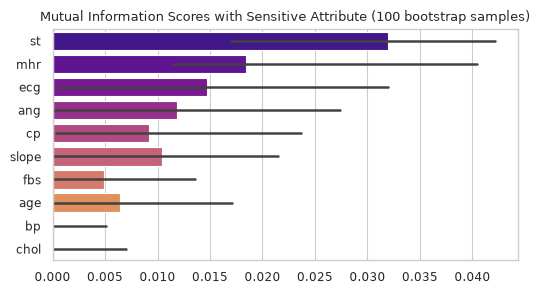

In [16]:
mutual_info_with_sens(
  X=heart_disease.drop(['cvd', 'sex'], axis=1),
  sens=heart_disease['sex']
)

# Processing

In [17]:
heart_disease_processed = heart_disease.copy()

## Dummy feature injection

In [18]:
heart_disease_processed['dummy_var'] = np.random.rand(heart_disease_processed.shape[0])

## Category re-indexing

In [19]:
# Indexing cp and slope at 0
heart_disease_processed['cp'] = heart_disease_processed['cp'] - 1
heart_disease_processed['slope'] = heart_disease_processed['slope'] - 1

heart_disease_processed = heart_disease_processed.astype(float)

## Training / test split

In [20]:
from sklearn.model_selection import train_test_split

heart_disease_processed['strata'] = heart_disease_processed['cvd'].astype(str) + "_" + heart_disease_processed['sex'].astype(str)

heart_disease_train, heart_disease_test = train_test_split(
  heart_disease_processed,
  test_size = 0.2,
  random_state = seed,
  stratify = heart_disease_processed['strata'] 
)

heart_disease_train.drop(columns="strata", inplace=True)
heart_disease_test.drop(columns="strata", inplace=True)

print(f"TRAIN SIZE: {heart_disease_train.shape[0]}")
print(f"TEST SIZE: {heart_disease_test.shape[0]}")

print("\n==== TRAINING: Target outcome by group ====")
print(pd.crosstab(heart_disease_train['sex'], heart_disease_train['cvd']))
print("\n==== TEST: Target outcome by group ====")
print(pd.crosstab(heart_disease_test['sex'], heart_disease_test['cvd']))


TRAIN SIZE: 596
TEST SIZE: 149

==== TRAINING: Target outcome by group ====
cvd  0.0  1.0
sex          
0.0  114   32
1.0  198  252

==== TEST: Target outcome by group ====
cvd  0.0  1.0
sex          
0.0   28    8
1.0   50   63


## Scaling

In [21]:
from processing_utils import StrataAwareRobustScaler

strata_scaler = StrataAwareRobustScaler(
  strata_col='sex', 
  continuous_cols=['mhr', 'age', 'chol', 'bp']
)
scaled_train = strata_scaler.fit_transform(heart_disease_train)
scaled_test = strata_scaler.transform(heart_disease_test)

scaled_train, scaled_test = scaled_train.align(scaled_test, join='left', axis=1)
scaled_train.reset_index(drop=True, inplace=True)
scaled_test.reset_index(drop=True, inplace=True)

In [22]:

scaled_train.to_csv(f'{PROJECT_ROOT}/z_data/heart_disease_train.csv', index=False)
scaled_test.to_csv(f'{PROJECT_ROOT}/z_data/heart_disease_test.csv', index=False)

# Split analysis

In [23]:
continuous_cols = ['age','chol','mhr','bp','st']
categorical_cols = ['cp', 'fbs','ecg','ang','slope']

## TRAINING

### Table 1

In [24]:
print_table_1(scaled_train, continuous_cols, categorical_cols)

+-----------------+----+------------+------------+------------+
|                 |    | Overall    | 0.0        | 1.0        |
+=================+====+============+============+============+
| n               |    | 596        | 146        | 450        |
+-----------------+----+------------+------------+------------+
| age, mean (SD)  |    | -0.1 (0.7) | -0.1 (0.7) | -0.1 (0.7) |
+-----------------+----+------------+------------+------------+
| cp, n (%)       |  0 | 33 (5.5)   | 7 (4.8)    | 26 (5.8)   |
+-----------------+----+------------+------------+------------+
|                 |  1 | 134 (22.5) | 51 (34.9)  | 83 (18.4)  |
+-----------------+----+------------+------------+------------+
|                 |  2 | 123 (20.6) | 37 (25.3)  | 86 (19.1)  |
+-----------------+----+------------+------------+------------+
|                 |  3 | 306 (51.3) | 51 (34.9)  | 255 (56.7) |
+-----------------+----+------------+------------+------------+
| bp, mean (SD)   |    | 0.2 (0.9)  | 0.

### Outcome classifier

In [25]:
from src.cevaehe_new.causal_validation import run_downstream_probe

y_probe_results = run_downstream_probe(
  features = scaled_train.drop(columns=['cvd', 'sex']).values,
  target = scaled_train['cvd'].values,
  sens = scaled_train['sex'].values,
  dict_prefix="",
  cf_features=None,
  seed=4
)

In [26]:
y_probe_results_df = pd.DataFrame(y_probe_results, index=[0])

def format_score(score):
  return round(score*100, 2)

print("---- GLOBAL PERFORMANCE ----\n")
print(y_probe_results_df.filter(regex="global_.*").apply(format_score).to_markdown(index=False))
for g in [0, 1]:
  group_results = y_probe_results_df.filter(regex=f"{g}_.*")
  print(f"\n---- GROUP {g} PERFORMANCE ----\n")
  print(group_results.apply(format_score).to_markdown(index=False))

---- GLOBAL PERFORMANCE ----

|   global_mean_auprc |   global_std_auprc |   global_mean_recall |   global_std_recall |   global_mean_precision |   global_std_precision |
|--------------------:|-------------------:|---------------------:|--------------------:|------------------------:|-----------------------:|
|               89.11 |               3.67 |                86.28 |                 4.6 |                   81.82 |                   3.46 |

---- GROUP 0 PERFORMANCE ----

|   0_mean_auprc |   0_std_auprc |   0_mean_recall |   0_std_recall |   0_mean_precision |   0_std_precision |
|---------------:|--------------:|----------------:|---------------:|-------------------:|------------------:|
|           78.3 |         16.49 |              90 |          13.33 |              51.56 |              6.35 |

---- GROUP 1 PERFORMANCE ----

|   1_mean_auprc |   1_std_auprc |   1_mean_recall |   1_std_recall |   1_mean_precision |   1_std_precision |
|---------------:|--------------:|-----

#### Without dummy variable

In [27]:
y_probe_results = run_downstream_probe(
  features = scaled_train.drop(columns=['cvd', 'sex', 'dummy_var']).values,
  target = scaled_train['cvd'].values,
  sens = scaled_train['sex'].values,
  dict_prefix="",
  cf_features=None,
  seed=4
)

In [28]:
y_probe_results_df = pd.DataFrame(y_probe_results, index=[0])

def format_score(score):
  return round(score*100, 2)

print("---- GLOBAL PERFORMANCE ----\n")
print(y_probe_results_df.filter(regex="global_.*").apply(format_score).to_markdown(index=False))
for g in [0, 1]:
  group_results = y_probe_results_df.filter(regex=f"{g}_.*")
  print(f"\n---- GROUP {g} PERFORMANCE ----\n")
  print(group_results.apply(format_score).to_markdown(index=False))

---- GLOBAL PERFORMANCE ----

|   global_mean_auprc |   global_std_auprc |   global_mean_recall |   global_std_recall |   global_mean_precision |   global_std_precision |
|--------------------:|-------------------:|---------------------:|--------------------:|------------------------:|-----------------------:|
|               89.35 |               3.85 |                85.94 |                6.15 |                    82.3 |                   4.02 |

---- GROUP 0 PERFORMANCE ----

|   0_mean_auprc |   0_std_auprc |   0_mean_recall |   0_std_recall |   0_mean_precision |   0_std_precision |
|---------------:|--------------:|----------------:|---------------:|-------------------:|------------------:|
|          77.24 |         17.06 |              90 |          13.33 |              54.47 |              6.22 |

---- GROUP 1 PERFORMANCE ----

|   1_mean_auprc |   1_std_auprc |   1_mean_recall |   1_std_recall |   1_mean_precision |   1_std_precision |
|---------------:|--------------:|-----

### Sex classifier

In [29]:
from src.cevaehe_new.causal_validation import run_test_classifier

race_classifier_results = run_test_classifier(
  features = scaled_train.drop(columns=['cvd', 'sex']).values,
  target = scaled_train['sex'].values,
  scoring = "balanced_accuracy",
  seed=4
)

In [30]:
print(f"X -> Race, balanced accuracy: {race_classifier_results[0]:.4f} (std {race_classifier_results[1]:.4f})")

X -> Race, balanced accuracy: 0.6020 (std 0.0398)
